# 03 — Train, Evaluate, Explain

This notebook picks up where `02_features_and_encoding.ipynb` left off: it loads the already
cleaned/featured dataset directly (no re-derivation of `01`/`02`'s work) and covers:

1. Temporal split vs. random split — why the "honest" evaluation looks worse.
2. A live ablation reproducing a real leakage finding from this project's development: including
   `order_month` as a numeric feature.
3. Loading the actual shipped models and inspecting them with SHAP.
4. A real end-to-end prediction via `PricePredictor`.

In [1]:
import time

import numpy as np
import pandas as pd
import shap

from sneakerml.config import PROCESSED_DIR, MODELS_DIR, RANDOM_SEED, SPLIT_DATE
from sneakerml.features import CATEGORICAL, NUMERIC, TARGET, add_features
from sneakerml.train import (
    FEATURES,
    build_pipeline,
    evaluate,
    load_artifacts,
    temporal_split,
    train_models,
)
from sneakerml.explain import Explainer
from sneakerml.predict import PricePredictor
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 20)

clean_df = pd.read_parquet(PROCESSED_DIR / "clean.parquet")
featured = add_features(clean_df).dropna(subset=[TARGET])
featured.shape

(90944, 20)

## 1. Temporal split vs. random split

`sneakerml.train.temporal_split` holds out everything on/after `SPLIT_DATE` (2019-01-01) as the
test set — the model only ever sees the past when it's evaluated. A random split, by contrast, can
put a sale from January 15th in training and a sale of the *same shoe two days later* in test: the
model effectively gets to peek at the near future.

Since our real use case ("what will this shoe sell for going forward?") is a forecasting problem,
the temporal split is the honest evaluation, even though — as we'll see — it makes the model look
worse. We fit two quick q50-only models here (`max_iter=100`, well under the shipped model's
early-stopped ~100 iterations from a `max_iter=1000` cap) purely to compare the two splitting
strategies live.

In [2]:
DEMO_MAX_ITER = 100

train_df, test_df = temporal_split(featured, SPLIT_DATE)
print(f"temporal split: {len(train_df):,} train / {len(test_df):,} test")

temporal_model = build_pipeline(quantile=0.5, max_iter=DEMO_MAX_ITER).fit(
    train_df[FEATURES], np.log1p(train_df[TARGET].to_numpy(dtype=float))
)
temporal_pred = np.expm1(temporal_model.predict(test_df[FEATURES]))
temporal_mae = float(np.mean(np.abs(temporal_pred - test_df[TARGET].to_numpy(dtype=float))))

rand_train, rand_test = train_test_split(
    featured, test_size=len(test_df) / len(featured), random_state=RANDOM_SEED, shuffle=True
)
random_model = build_pipeline(quantile=0.5, max_iter=DEMO_MAX_ITER).fit(
    rand_train[FEATURES], np.log1p(rand_train[TARGET].to_numpy(dtype=float))
)
random_pred = np.expm1(random_model.predict(rand_test[FEATURES]))
random_mae = float(np.mean(np.abs(random_pred - rand_test[TARGET].to_numpy(dtype=float))))

print(f"temporal-split MAE: ${temporal_mae:,.2f}")
print(f"random-split MAE:   ${random_mae:,.2f}")

temporal split: 75,795 train / 15,149 test


temporal-split MAE: $43.07
random-split MAE:   $42.41


The random split typically comes out ahead on MAE — not because it's a better model, but
because it's an easier, less realistic test. This gap (`temporal_split_mae` vs. `random_split_mae`)
is tracked as a real diagnostic in `sneakerml.train.evaluate` and stored in the shipped
`metadata.json`.

## 2. The `order_month` ablation — a real leakage finding from this project

While developing the feature set (`sneakerml.features`), `order_month` (the calendar month, 1-12,
of the sale) was tried as a numeric feature and then deliberately removed. The reason is spelled
out in `features.py`'s comment above the `NUMERIC` constant:

> The training data only spans ~18 months (Aug 2017 - Feb 2019), so calendar months 1-7 (Jan-Jul)
> each occur in exactly one year (2018) in the data. A model trained on `order_month` learns
> "January ≈ $385" from 2018 and wrongly extrapolates that price level onto January 2019 in the
> test split — an implicit year-proxy, exactly the leakage trap that omitting `order_year` was
> meant to avoid in the first place.

That's a real, previously-measured result (MAE $118.58 / MAPE 34.4% / coverage 0.173 with
`order_month`, vs. $42.06 / 9.5% / 0.768 without it, from Task 5's development run). Rather than
just repeating those numbers, we reproduce the comparison **live** here: two q50 models trained on
the *same* temporal split, one with `order_month` added to its numeric feature list and one
without, both at `max_iter=100` for a fast, re-runnable demonstration (not the full shipped
`max_iter` — this is a smaller/faster run, so don't expect these exact numbers to match the shipped
`metadata.json`).

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


def build_pipeline_with_numeric(quantile, numeric_cols, max_iter=DEMO_MAX_ITER):
    """Same shape as train.build_pipeline, but with a swappable numeric column list
    so we can add order_month back in for this ablation only."""
    preprocessor = ColumnTransformer(
        [
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=False),
                CATEGORICAL,
            ),
            ("num", "passthrough", numeric_cols),
        ]
    )
    model = HistGradientBoostingRegressor(
        loss="quantile",
        quantile=quantile,
        max_iter=max_iter,
        learning_rate=0.06,
        max_depth=6,
        random_state=RANDOM_SEED,
        early_stopping=True,
        n_iter_no_change=10,
        validation_fraction=0.1,
        tol=1e-3,
    )
    return Pipeline([("preprocessor", preprocessor), ("model", model)])


def fit_and_score(numeric_cols):
    """Fit q10/q50/q90 on `train_df` with the given numeric feature list and
    score on `test_df`, returning MAE/MAPE (from q50) plus q10-q90 coverage --
    the same three headline metrics `train.evaluate` reports for the shipped
    model."""
    cols = CATEGORICAL + numeric_cols
    y_train_log = np.log1p(train_df[TARGET].to_numpy(dtype=float))
    y_true = test_df[TARGET].to_numpy(dtype=float)

    preds = {}
    for name, q in (("q10", 0.10), ("q50", 0.50), ("q90", 0.90)):
        pipe = build_pipeline_with_numeric(q, numeric_cols).fit(train_df[cols], y_train_log)
        preds[name] = np.expm1(pipe.predict(test_df[cols]))

    mae = float(np.mean(np.abs(preds["q50"] - y_true)))
    mape = float(np.mean(np.abs(preds["q50"] - y_true) / y_true))
    low = np.minimum(preds["q10"], preds["q90"])
    high = np.maximum(preds["q10"], preds["q90"])
    coverage = float(np.mean((y_true >= low) & (y_true <= high)))
    return mae, mape, coverage


numeric_without_month = list(NUMERIC)
numeric_with_month = list(NUMERIC) + ["order_month"]

mae_without, mape_without, cov_without = fit_and_score(numeric_without_month)
mae_with, mape_with, cov_with = fit_and_score(numeric_with_month)

ablation = pd.DataFrame(
    [
        {"config": "without order_month (shipped)", "mae_usd": mae_without, "mape": mape_without, "coverage": cov_without},
        {"config": "with order_month (ablation)", "mae_usd": mae_with, "mape": mape_with, "coverage": cov_with},
    ]
)
ablation

,config,mae_usd,mape,coverage
0,without order_month (shipped),43.067324,0.095987,0.804740
1,with order_month (ablation),110.455418,0.330843,0.376989


**The result, freshly re-run in this notebook:** adding `order_month` back in makes the
temporally-held-out MAE, MAPE, *and* q10-q90 coverage all *worse*, not better — despite giving the
model strictly more information at training time. That's the signature of a feature that memorises a spurious
year-specific pattern (calendar month standing in for calendar year, since 2019's Jan/Feb are the
only repeat of an already-seen month) rather than learning something that generalises forward in
time. This is exactly why `sneakerml.features.NUMERIC` excludes `order_month`, even though
`add_features` still computes the column (it's kept only as this teaching artifact).

### Aside: why the shipped model uses non-default early-stopping settings

The pipeline above (and the real shipped `train.build_pipeline`) sets
`early_stopping=True, n_iter_no_change=10, validation_fraction=0.1, tol=1e-3` explicitly.
`HistGradientBoostingRegressor`'s default `tol` is `1e-7` — so small that on this dataset the
internal validation pinball loss "improves" by a hair almost every round, and early stopping never
actually fires before hitting `max_iter`. With the old default tol and `max_iter=400`, the q10/q90
models kept fitting well past the point where their calibration holds on held-out data, collapsing
interval coverage to 0.596. Raising `tol` to `1e-3` (a real plateau in log1p(price) units, not
numerical noise) lets early stopping trigger for real, and restores coverage to ~0.80 — see
`sneakerml.train`'s module comment for the full story.

## 3. Loading the real shipped models

We load the actual `q10/q50/q90.joblib` + `metadata.json` that ship with this repo (fast — no
fitting happens here) and inspect their real recorded metrics.

In [4]:
models, metadata = load_artifacts(MODELS_DIR)
metadata["metrics"]

{'n_test': 15149,
 'mae': 42.859176573570174,
 'mape': 0.09552308687419776,
 'coverage': 0.803881444319757,
 'crossing_rate': 0.0,
 'pinball_q10': 8.718033980684012,
 'pinball_q50': 21.429588286785087,
 'pinball_q90': 15.531342976346933,
 'temporal_split_mae': 42.859176573570174,
 'random_split_mae': 41.35477511790745}

In [5]:
print(f"MAE:      ${metadata['metrics']['mae']:.2f}")
print(f"MAPE:     {metadata['metrics']['mape']*100:.1f}%")
print(f"Coverage: {metadata['metrics']['coverage']:.3f}")
print(f"temporal_split_mae vs random_split_mae: "
      f"${metadata['metrics']['temporal_split_mae']:.2f} vs "
      f"${metadata['metrics']['random_split_mae']:.2f}")

MAE:      $42.86
MAPE:     9.6%
Coverage: 0.804
temporal_split_mae vs random_split_mae: $42.86 vs $41.35


## 4. SHAP: global summary and one local waterfall

`sneakerml.explain.Explainer` wraps `shap.TreeExplainer` and folds per-one-hot-level attributions
back onto original feature names. We use its underlying preprocessor/model directly here so we can
hand `shap` the transformed matrix for the summary plot, and use `Explainer.contributions` for the
human-readable local explanation later via `PricePredictor`.

In [6]:
q50_pipe = models["q50"]
explainer = Explainer(q50_pipe)

# sample for a fast, readable SHAP summary plot
shap_sample = test_df.sample(n=min(500, len(test_df)), random_state=RANDOM_SEED)
X_shap = shap_sample[FEATURES]

shap_by_col = explainer.shap_by_column(X_shap)
shap_by_col.shape

(500, 13)

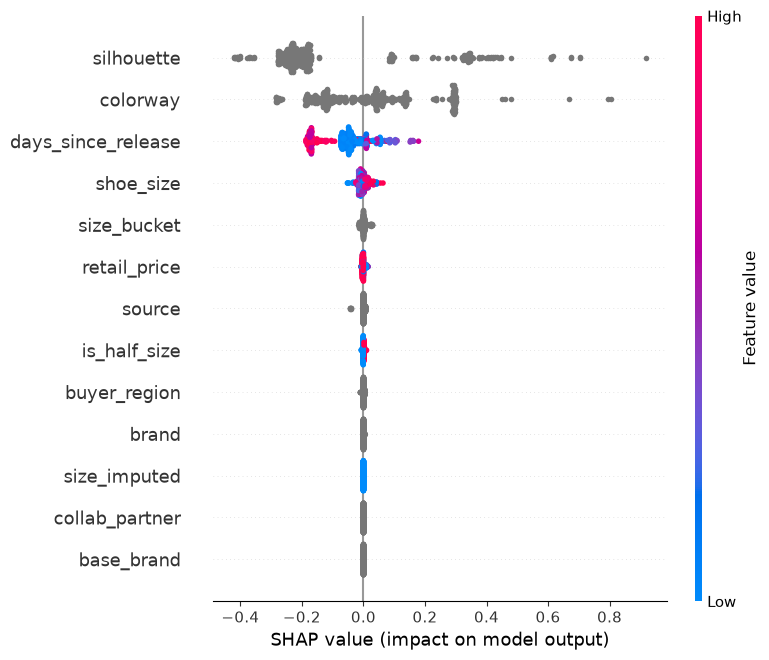

In [7]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_by_col.to_numpy(),
    X_shap[explainer.input_features],
    feature_names=explainer.input_features,
    show=False,
)
plt.tight_layout()
plt.show()

And a waterfall plot for a single real prediction — the first row of the SHAP sample above —
showing how each feature pushes that one prediction up or down from the model's baseline (in
log1p(price) units, the space the model is fit in).

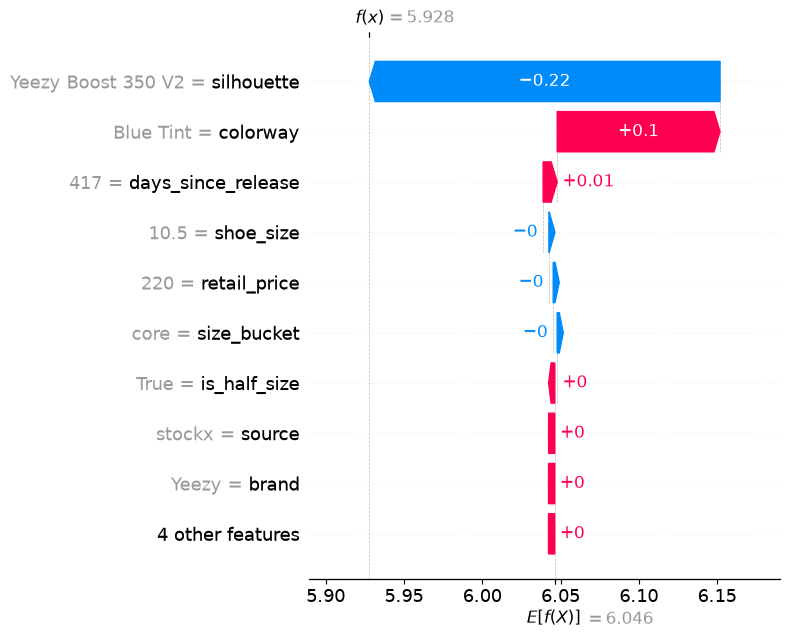

In [8]:
row_shap_values = shap_by_col.iloc[0].to_numpy()
base_value = float(np.ravel(explainer.explainer.expected_value)[0])

explanation = shap.Explanation(
    values=row_shap_values,
    base_values=base_value,
    data=X_shap[explainer.input_features].iloc[0].to_numpy(),
    feature_names=explainer.input_features,
)
shap.plots.waterfall(explanation, show=False)
plt.tight_layout()
plt.show()

## 5. A real end-to-end prediction

Finally, the actual user-facing entry point: `PricePredictor.load()` plus a real `.predict()` call
on a sneaker looked up via `.search()`.

In [9]:
predictor = PricePredictor.load()
hits = predictor.search("yeezy", limit=5)
for h in hits:
    print(h["id"], "-", h["display_name"])

adidas-yeezy-boost-350-v2-beluga-2pt0 - Adidas Yeezy Boost 350 V2 "Beluga 2Pt0"
adidas-yeezy-boost-350-v2-butter - Adidas Yeezy Boost 350 V2 "Butter"
adidas-yeezy-boost-350-v2-blue-tint - Adidas Yeezy Boost 350 V2 "Blue Tint"
adidas-yeezy-boost-350-v2-cream-white - Adidas Yeezy Boost 350 V2 "Cream White"
adidas-yeezy-boost-350-v2-zebra - Adidas Yeezy Boost 350 V2 "Zebra"


In [10]:
sneaker_id = hits[0]["id"]
result = predictor.predict(sneaker_id, size=10.0)
result

{'sneaker': {'id': 'adidas-yeezy-boost-350-v2-beluga-2pt0',
  'sku': '2C3D2E79',
  'sneaker_name': 'Adidas-Yeezy-Boost-350-V2-Beluga-2Pt0',
  'display_name': 'Adidas Yeezy Boost 350 V2 "Beluga 2Pt0"',
  'brand': 'Yeezy',
  'silhouette': 'Yeezy Boost 350 V2',
  'colorway': 'Beluga 2Pt0',
  'retail_price': 220.0,
  'release_date': '2017-11-25',
  'n_sales': 9351,
  'median_sale': 399.0,
  'sizes_seen': [4.0,
   4.5,
   5.0,
   5.5,
   6.0,
   6.5,
   7.0,
   7.5,
   8.0,
   8.5,
   9.0,
   9.5,
   10.0,
   10.5,
   11.0,
   11.5,
   12.0,
   12.5,
   13.0,
   13.5,
   14.0,
   14.5,
   16.0]},
 'size': 10.0,
 'as_of': '2019-02-23',
 'low': 345.08468057893816,
 'mid': 386.62363206726775,
 'high': 448.5134619072753,
 'crossed': False,
 'retail_price': 220.0,
 'premium_pct': 75.73801457603079,
 'extrapolated': False,
 'contributions': [{'feature': 'silhouette',
   'value': 'Yeezy Boost 350 V2',
   'effect_pct': -19.85764932993451},
  {'feature': 'colorway',
   'value': 'Beluga 2Pt0',
   'ef

`extrapolated=True` would mean the requested date puts this shoe further past its release than
anything the model saw during training (`days_since_release` beyond `max_days_since_release` in
`metadata.json`) — the model still returns a number, but it's flagging that it's extrapolating
past the edge of its training data. `crossed=True` would mean the three independently-trained
quantile models (q10/q50/q90) didn't come out in the expected low/mid/high order for this
particular row before being sorted — a reminder that nothing structurally forces q10 <= q50 <= q90
across three separately fit models.

In [11]:
print(f"extrapolated: {result['extrapolated']}")
print(f"crossed:      {result['crossed']}")
print(f"price range:  ${result['low']:.2f} - ${result['mid']:.2f} - ${result['high']:.2f}")
print("top contributions:")
for c in result["contributions"][:5]:
    print(f"  {c['feature']:<20} {c['value']!r:<20} {c['effect_pct']:+.1f}%")

extrapolated: False
crossed:      False
price range:  $345.08 - $386.62 - $448.51
top contributions:
  silhouette           'Yeezy Boost 350 V2' -19.9%
  colorway             'Beluga 2Pt0'        +15.3%
  shoe_size            10.0                 -0.7%
  days_since_release   455.0                +0.6%
  retail_price         220.0                -0.3%


## Summary

- A random split flatters the model relative to the honest temporal split — see the real MAE gap
  computed above.
- Adding `order_month` back into the numeric feature set makes the temporally-held-out model
  *worse*, reproducing (with a faster, smaller live run) a real leakage finding from this project's
  development history — see the ablation table above for this run's real numbers.
- The shipped model's non-default early-stopping `tol` exists because the sklearn default never
  triggers early stopping on this dataset, which otherwise collapses quantile-interval coverage.
- SHAP attributes predictions back to original (not one-hot-exploded) feature names, and
  `PricePredictor` ties models + metadata + catalog together into one real, explained prediction.